In [17]:
import os
import dill

import numpy as np
from matplotlib import pyplot as plt

import TwoPUtils
import STX3KO_analyses as stx

ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
ko_mice = stx.ymaze_sess_deets.ko_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
def update_sess_dict(mouse, f):
    scan_str = "%s_%03d_%03d" % (f['scene'],f['session'],f['scan'])

    source_folder = "/mnt/BigDisk/2P_scratch"
    source_stem = os.path.join(source_folder, mouse, f['date'], f['scene'], scan_str)

    f['mouse']=mouse
    f.update({'vr_filename': os.path.join("/mnt/BigDisk/VRData",f['mouse'],f['date'],"%s_%d.sqlite" %(f['scene'],f['session'])),
              'scan_number': f['scan'],
              'prompt_for_keys': False,
              'VR_only': True,
              'scanner': "NLW",
             })
    return f

In [19]:
ko_sessions = stx.ymaze_sess_deets.KO_behavior_sessions
ctrl_sessions = stx.ymaze_sess_deets.CTRL_behavior_sessions
sparse_sessions = stx.ymaze_sess_deets.SparseKO_sessions

In [20]:
def run_and_save(fdict,comb_frames=0):

            
    sess = stx.session.YMazeSession(**fdict)
    sess.align_VR_to_2P()
    sess.get_trial_info()

    # added 11/12/2025
    dt = np.ediff1d(sess.vr_data['time'], to_begin=1E-3)
    print(dt.mean())


    speed = np.nan*sess.vr_data['t'].to_numpy()
    for t, (start,stop) in enumerate(zip(sess.trial_start_inds.to_list(), sess.teleport_inds.to_list())):
       
        speed[start:stop] = 10*np.diff(sess.vr_data['t'].iloc[start-1:stop])/dt[start:stop]
        
    sess.add_timeseries(speed=speed)
   
    sess.add_pos_binned_trial_matrix('speed')
    # sess.add_timeseries(speed=sess.vr_data['dz'].values/dt*10)
    # sess.add_pos_binned_trial_matrix('speed')
    
    # sess.add_timeseries(speed=sess.vr_data['dz']._values)
    # sess.add_pos_binned_trial_matrix('speed') #, speed_thr=.01, speed = sess.timeseries['speed_raw'].ravel())
    
    

    licks = np.copy(sess.vr_data['lick'].values)
    licks[licks>1]=1
    licks[1:] = 1.*((licks[1:]-licks[:-1])>0)
    sess.add_timeseries(licks=licks)
    # sess.timeseries['licks'][sess.timeseries['licks']>1]=1
    sess.add_pos_binned_trial_matrix('licks')

    # sess.add_timeseries(licks_rate=licks/dt)
    # sess.add_pos_binned_trial_matrix('licks_rate') #,speed_thr=.01, speed = sess.timeseries['speed_raw'].ravel())
    
    
    
    time = sess.vr_data['time']

    reward_inds = np.argwhere(sess.vr_data['reward']._values==1).ravel()
    for r in reward_inds:
        licks[((time-time[r])>=0)&((time-time[r])<2)] = 0

    sess.add_timeseries(nonconsum_licks = licks)
    sess.add_pos_binned_trial_matrix('nonconsum_licks')
    
    sess.add_timeseries(licks_sum=licks)
    sess.add_pos_binned_trial_matrix('licks_sum',use_sum=True)
    
    if fdict['mouse']=='4467975.4' and fdict['date']=="28_09_2020":
        print("nan it")
        for key in ('licks', 'nonconsum_licks', 'licks_sum'):
            print(sess.trial_matrices[key].shape)
            sess.trial_matrices[key][34:68,:]=np.nan
            fig,ax = plt.subplots()
            ax.imshow(sess.trial_matrices[key])
            print(np.isnan(sess.trial_matrices[key]).sum())
    
    for key in ('licks', 'nonconsum_licks', 'licks_sum'):
        print(np.isnan(sess.trial_matrices[key]).sum())
    
    sess._abc_impl = None # 11/12/25
    TwoPUtils.sess.save_session(sess,'/mnt/BigDisk/YMaze_VR_Pkls')
    return comb_frames+sess.vr_data.shape[0]


In [21]:
for mouse, flist in ctrl_sessions.items():
    for i, f in enumerate(flist):
        if isinstance(f, tuple):
            for _f in f:
                _f = update_sess_dict(mouse, _f)
                _ = run_and_save(_f)
        else:
            f = update_sess_dict(mouse, f)
            _ = run_and_save(f)

Fixing teleports
1
2
3
4
5
0.02257453056955214
4
4
4
Fixing teleports
1
2
3
4
5
0.0229524900877776
8
8
8
Fixing teleports
1
2
3
4
5
0.02256653729310139
12
12
12
Fixing teleports
1
2
3
4
5
0.022398276692773986
11
11
11
Fixing teleports
1
2
3
4
5
0.022303801517408205
0
0
0
Fixing teleports
1
2
3
4
5
0.022868670853281932
5
5
5
Fixing teleports
1
0.023824689745264534
1
1
1
Fixing teleports
1
2
3
0.02241451718259595
0
0
0
Fixing teleports
1
2
3
4
5
0.022756891698093168
3
3
3
Fixing teleports
1
0.023409006783660223
0
0
0
Fixing teleports
1
2
3
0.022490989364495798
3
3
3
Fixing teleports
1
2
3
4
5
0.022323823679481776
3
3
3
Fixing teleports
1
2
3
4
5
0.022956048133233552
5
5
5
Fixing teleports
1
2
3
4
5
0.022425453072312845
4
4
4
Fixing teleports
0.02353273696886289
0
0
0
Fixing teleports
1
2
3
4
0.022671046604832244
10
10
10
Fixing teleports
1
2
3
4
5
0.022770442997777075
10
10
10
Fixing teleports
1
2
3
4
5
0.022460230566110646
14
14
14
Fixing teleports
1
0.02137877042132416
4
4
4
Fixing tel

4467975.1 ({'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0, 'mouse': '4467975.1', 'vr_filename': '/mnt/BigDisk/VRData/4467975.1/28_09_2020/YMaze_LNovel_1.sqlite', 'scan_number': 3, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}, {'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1, 'mouse': '4467975.1', 'vr_filename': '/mnt/BigDisk/VRData/4467975.1/28_09_2020/YMaze_LNovel_6.sqlite', 'scan_number': 14, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'})
Fixing teleports
0.025513863031914892
0
0
0
Fixing teleports
1
2
3
4
0.025372855277278547
2
2
2
4467975.1 {'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2, 'mouse': '4467975.1', 'vr_filename': '/mnt/BigDisk/VRData/4467975.1/29_09_2020/YMaze_LNovel_1.sqlite', 'scan_number': 3, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}
Fixing teleport

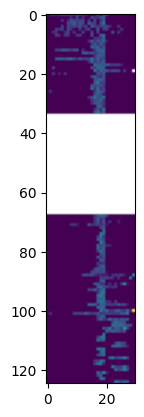

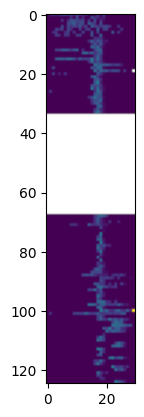

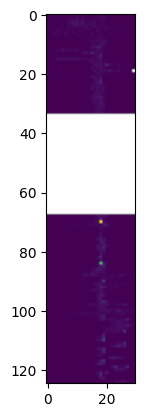

In [22]:
for mouse, flist in ko_sessions.items():
    for i, f in enumerate(flist):
        print(mouse, f)
        if isinstance(f, tuple):
            for _f in f:
                _f = update_sess_dict(mouse, _f)
                _ = run_and_save(_f)
        else:
            f = update_sess_dict(mouse, f)
            _ = run_and_save(f)

In [23]:
for mouse, flist in sparse_sessions.items():
    for i, f in enumerate(flist):

        if mouse == 'SparseKO_09' and i ==2:
            continue

        f_ = update_sess_dict(mouse, f)
        _ = run_and_save(f_)

Fixing teleports
1
2
3
4
5
0.013881553260019577
0
0
0
Fixing teleports
1
2
3
4
5
0.013612710221673542
0
0
0
Fixing teleports
1
2
3
4
5
0.013847149222717323
0
0
0
Fixing teleports
1
2
3
4
5
0.013657336857354551
0
0
0
Fixing teleports
1
2
3
4
5
0.014159637395946435
0
0
0
Fixing teleports
1
2
3
4
5
0.013769089815269643
0
0
0
Fixing teleports
1
2
3
4
5
6
7
0.013933227813155664
1
1
1
Fixing teleports
1
2
3
4
5
0.015311970456734925
0
0
0
Fixing teleports
1
2
3
4
5
0.015113995624062739
0
0
0
Fixing teleports
1
2
3
4
5
0.013128118800969802
0
0
0
Fixing teleports
1
2
3
4
5
0.015004429393747359
0
0
0
Fixing teleports
1
2
3
4
5
0.013137974245959728
0
0
0
Fixing teleports
1
2
3
4
5
0.014844887166080713
0
0
0
Fixing teleports
1
2
3
4
5
6
7
0.01437044860584386
0
0
0
Fixing teleports
1
2
3
4
5
6
7
0.014460693522071836
0
0
0
Fixing teleports
1
2
3
4
5
0.01510823737699518
0
0
0
Fixing teleports
1
2
3
4
5
0.00920447302146248
0
0
0
Fixing teleports
1
2
3
4
5
0.014856311136508787
0
0
0
Fixing teleports
1


In [19]:
def update_and_save(sess):


    # added 11/12/2025
    dt = np.ediff1d(sess.vr_data['time'], to_begin=1E-3)
    # print(dt.mean())
    

    speed = np.nan*sess.vr_data['t'].to_numpy()
    # block = np.nan*sess.vr_data['t'].to_numpy()
    for t, (start,stop) in enumerate(zip(sess.trial_start_inds.to_list(), sess.teleport_inds.to_list())):
        # print(stop-start)
        # print(np.diff(sess.vr_data['t'].iloc[start-1:stop]).shape)
        speed[start:stop] = 10*np.diff(sess.vr_data['t'].iloc[start-1:stop])/dt[start:stop]
        # block[start:stop] = sess.trial_info['block_number'][t]
    sess.add_timeseries(speed=speed)
    # sess.add_timeseries(speed=sess.vr_data['dz'].values/dt)
    sess.add_pos_binned_trial_matrix('speed')
    
    
    sess.add_timeseries(licks_rate=sess.vr_data['lick'].values/dt)
    sess.add_pos_binned_trial_matrix('licks_rate') #,speed_thr=.01, speed = sess.timeseries['speed_raw'].ravel())
    

    licks = np.copy(sess.vr_data['lick'].values)
    licks[licks>1]=1
    # licks[1:] = 1.*((licks[1:]-licks[:-1])>0)
    licks[1:] = 1.*(licks[1:]>licks[:-1])
    sess.add_timeseries(licks=licks)
    # sess.timeseries['licks'][sess.timeseries['licks']>1]=1
    sess.add_pos_binned_trial_matrix('licks')
    
    
    time = sess.vr_data['time']

    reward_inds = np.argwhere(sess.vr_data['reward']._values==1).ravel()
    for r in reward_inds:
        licks[((time-time[r])>=0)&((time-time[r])<2)] = 0

    sess.add_timeseries(nonconsum_licks = licks)
    sess.add_pos_binned_trial_matrix('nonconsum_licks')
    
    sess.add_timeseries(licks_sum=licks)
    sess.add_pos_binned_trial_matrix('licks_sum',use_sum=True)
    
    
    for key in ('licks', 'nonconsum_licks', 'licks_sum'):
        print(np.isnan(sess.trial_matrices[key]).sum())
    
    sess._abc_impl = None # 11/12/25
    TwoPUtils.sess.save_session(sess,'/mnt/BigDisk/YMaze_VR_Pkls')
    return sess.vr_data.shape[0]


In [20]:
import pathlib
pkldir = pathlib.Path('/mnt/BigDisk/YMaze_VR_Pkls')

for mouse, flist in ctrl_sessions.items():
    for deets in flist:
        if isinstance(deets, tuple):
            for _deets in deets:
                sess = stx.session.YMazeSession.from_file(
                    os.path.join(pkldir / mouse, _deets['date'], "%s_%d.pkl" % (_deets['scene'], _deets['session'])),
                    verbose=False, novel_arm=_deets['novel_arm'])

    # deets = ctrl_sessions[mouse][0]
        else:
            sess = stx.session.YMazeSession.from_file(
                        os.path.join(pkldir / mouse, deets['date'], "%s_%d.pkl" % (deets['scene'], deets['session'])),
                        verbose=False, novel_arm=deets['novel_arm'])
        
        update_and_save(sess)

4
4
4
8
8
8
12
12
12
11
11
11
0
0
0
5
5
5
0
0
0
3
3
3
3
3
3
3
3
3
5
5
5
4
4
4
10
10
10
10
10
10
14
14
14
5
5
5
10
10
10
5
5
5
0
0
0
1
1
1
3
3
3
12
12
12
2
2
2
2
2
2
0
0
0
10
10
10
2
2
2
5
5
5
4
4
4
9
9
9
15
15
15
7
7
7
3
3
3
5
5
5
2
2
2
0
0
0
7
7
7
8
8
8
0
0
0
2
2
2
3
3
3
1
1
1
2
2
2
3
3
3
5
5
5
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
0
0
0
0
0
0
1
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
2
2
2
3
3
3
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


In [21]:
for mouse, flist in ko_sessions.items():
    for deets in flist:
        if isinstance(deets, tuple):
            for _deets in deets:
                sess = stx.session.YMazeSession.from_file(
                    os.path.join(pkldir / mouse, _deets['date'], "%s_%d.pkl" % (_deets['scene'], _deets['session'])),
                    verbose=False, novel_arm=_deets['novel_arm'])

    # deets = ctrl_sessions[mouse][0]
        else:
            sess = stx.session.YMazeSession.from_file(
                        os.path.join(pkldir / mouse, deets['date'], "%s_%d.pkl" % (deets['scene'], deets['session'])),
                        verbose=False, novel_arm=deets['novel_arm'])
        
        update_and_save(sess)

2
2
2
2
2
2
2
2
2
1
1
1
0
0
0
0
0
0
0
0
0
2
2
2
0
0
0
10
10
10
3
3
3
3
3
3
1
1
1
3
3
3
4
4
4
0
0
0
1
1
1
0
0
0
2
2
2
1
1
1
0
0
0
0
0
0
0
0
0
1
1
1
0
0
0
0
0
0
0
0
0
1
1
1
0
0
0
1
1
1
6
6
6
2
2
2
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
1
1
1
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


KeyboardInterrupt: 

In [11]:
mouse = '4467975.4'
f = ko_sessions[mouse][0]
# print(f)
f_ = update_sess_dict(mouse,f)
# print(mouse, f_)
_ = run_and_save(f_)

OperationalError: unable to open database file

{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0, 'mouse': '4467975.4', 'vr_filename': '/home/mplitt/VR_scratch/4467975.4/28_09_2020/YMaze_LNovel_1.sqlite', 'scan_number': 5, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}


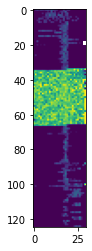

In [ ]:
sess = stx.utilities.load_vr_day(mouse,0)
fig,ax = plt.subplots()
ax.imshow(sess.trial_matrices['licks'])

In [ ]:
for d in (ko_sessions, ctrl_sessions):
    
    for mouse, sess_list in d.items():
        print(mouse)
        for f in sess_list:
            if isinstance(f,dict):
                f_ = update_sess_dict(mouse,f)
                print(mouse, f_)
                _ = run_and_save(f_)
            elif isinstance(f, tuple) or isinstance(f, list):
                comb_frames = 0
                for _f in f:
                    
                    f_ = update_sess_dict(mouse,_f)
                    print(mouse, f_)
                    comb_frames = run_and_save(f_,comb_frames=comb_frames)


4467975.1
4467975.1 {'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0, 'mouse': '4467975.1', 'vr_filename': '/home/mplitt/VR_scratch/4467975.1/28_09_2020/YMaze_LNovel_1.sqlite', 'scan_number': 3, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}
Fixing teleports
4467975.1 {'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1, 'mouse': '4467975.1', 'vr_filename': '/home/mplitt/VR_scratch/4467975.1/28_09_2020/YMaze_LNovel_6.sqlite', 'scan_number': 14, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}
Fixing teleports
4467975.1 {'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2, 'mouse': '4467975.1', 'vr_filename': '/home/mplitt/VR_scratch/4467975.1/29_09_2020/YMaze_LNovel_1.sqlite', 'scan_number': 3, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}
Fixing teleports
4467975.1 {'date': '30_09_2020'

In [ ]:
basedir = "/home/mplitt/YMaze_VR_Pkls"

mouse = 'Cre9'
f_dict = ko_sessions[mouse][-1]
print(f_dict[0])
f = f_dict[1]

file = os.path.join(basedir, mouse, f['date'], "%s_%d.pkl" % (f['scene'], f['session']))
sess = stx.session.YMazeSession.from_file(file)

{'date': '24_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 6, 'mouse': 'Cre9', 'vr_filename': '/home/mplitt/VR_scratch/Cre9/24_10_2021/YMaze_LNovel_1.sqlite', 'scan_number': 3, 'prompt_for_keys': False, 'VR_only': True, 'scanner': 'NLW'}


In [ ]:
sess.trial_matrices.keys()

dict_keys(['licks', 'bin_edges', 'bin_centers', 'speed'])

In [ ]:
sess.trial_info['LR']

array([ 1., -1.,  1.,  1.,  1., -1.,  1.,  1., -1., -1.,  1.,  1., -1.,
       -1.,  1., -1.,  1., -1., -1., -1., -1., -1., -1.,  1.,  1., -1.,
       -1., -1.,  1., -1.,  1., -1.,  1., -1.,  1.,  1.,  1.,  1., -1.,
       -1.,  1., -1.,  1.,  1.,  1.,  1., -1.,  1.,  1., -1.,  1., -1.,
        1., -1.])

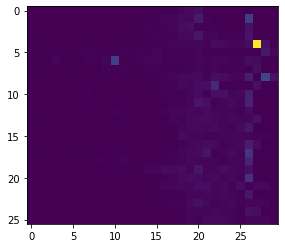

In [ ]:
fig, ax = plt.subplots()
ax.imshow(sess.trial_matrices['licks'][sess.trial_info['LR']==-1])